<h2>Naive Bayes</h2>

Naive Bayes is a simple yet powerful classification algorithm based on Bayes' Theorem, assuming feature independence. It’s widely used for tasks like spam detection, sentiment analysis, and document categorization.

What is Naive Bayes?

Naive Bayes is a probabilistic classifier that predicts the class of a data point based on the likelihood of its features.

It’s called “naive” because it assumes all features are independent — which is rarely true in real life, but the assumption simplifies computation and often works surprisingly well.

Core Concept: Bayes’ Theorem :

Bayes’ Theorem calculates the probability of a hypothesis (class) given observed evidence (features):

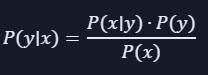

Where:

𝑃
(
𝑦
∣
𝑥
)
: Posterior probability of class 
𝑦
 given features 
𝑥

𝑃
(
𝑥
∣
𝑦
)
: Likelihood of features given class

𝑃
(
𝑦
)
: Prior probability of class

𝑃
(
𝑥
)
: Evidence (overall probability of features)

How Naive Bayes Works
Calculate prior probabilities for each class from training data.

Estimate likelihoods of each feature given a class.

Multiply likelihoods assuming independence:

𝑃
(
𝑥
∣
𝑦
)
=
𝑃
(
𝑥
1
∣
𝑦
)
⋅
𝑃
(
𝑥
2
∣
𝑦
)
⋅
…
⋅
𝑃
(
𝑥
𝑛
∣
𝑦
)

Apply Bayes’ Theorem to compute posterior probabilities.

Choose the class with the highest posterior probability.

<h3>Types of Naive Bayes</h3>

Gaussian Naive Bayes: Assumes features follow a normal distribution (used for continuous data).

Multinomial Naive Bayes: Used for discrete counts like word frequencies in text.

Bernoulli Naive Bayes: Works with binary/boolean features.

Advantages:
    
Fast and efficient even with large datasets.

Performs well with text classification and spam filtering.

Requires less training data compared to other models.

In [ ]:
f = open('D:/Ashwath/NS_Trainings/MyStuff/comments.txt')
lines = f.readlines()
words=[]
sentiment=[]
for line in lines:
    w=line.strip().lower().split(',')  #[i love you, pos]
    words+=w[0].split() #[i,love,you]
    s=0
    if w[1].strip()=='pos':
        s=1
    sentiment.append(s)
print(words)
unique = list(set(words)) #set function returns the unique data from the list
print(sentiment)
print(unique)

In [ ]:
import numpy as np
X=np.zeros((len(lines),len(unique)))
print(X)

In [ ]:
#['kill', 'love', 'hate', 'you', 'to', 'admire', 'i']
c=0
for w in unique:     
    r=0
    for ln in lines: 
        ln=ln.lower() 
        if w in ln:            
            X[r,c]=1 
        r+=1
    c+=1
print(X)

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X,sentiment) # training the model
ycap=model.predict(X)
print(np.c_[sentiment,ycap])

In [14]:
#function to find accuarcy

def acc_clf(y,ycap):
    y=np.array(y)
    ycap=np.array(ycap)
    r = y == ycap
    pcnt = r[r==True].size
    n=y.size
    acc = pcnt/n * 100
    return acc

In [ ]:
acc_clf(sentiment,ycap)

In [ ]:
#accuracy using bultin library function

from sklearn.metrics import accuracy_score
acc=accuracy_score(sentiment,ycap)
print("Accuarcy : ",acc*100)

In [ ]:
# confusion matrix in sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# confusion matrix
matrix = confusion_matrix(sentiment,ycap, labels=[1,0])
print('Confusion matrix : \n',matrix)

# outcome values order in sklearn
tp, fn, fp, tn = confusion_matrix(sentiment,ycap,labels=[1,0]).reshape(-1)
print('Outcome values : \n', tp, fn, fp, tn)

# classification report for precision, recall f1-score and accuracy
matrix = classification_report(sentiment,ycap,labels=[1,0])
print('Classification report : \n',matrix)